# Deutsch's Algorithm

Deutsch Algorithm Analysis: Balanced Oracle

1. Circuit Visualisation

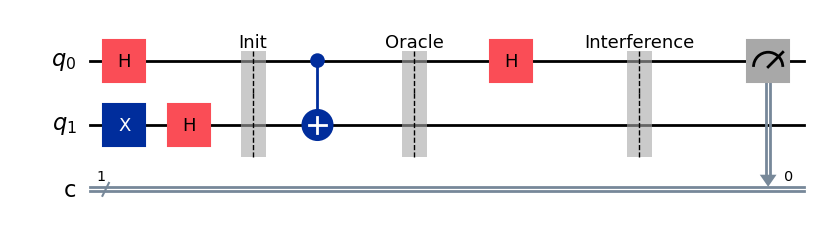

2. Unitary Evolution

The 4x4 unitary matrix describing this specific oracle circuit:


<IPython.core.display.Latex object>

3. Quantum State Representation

Exact Statevector prior to measurement:


<IPython.core.display.Latex object>

4. State Visualisation

State prior to measurement (Bloch Spheres):


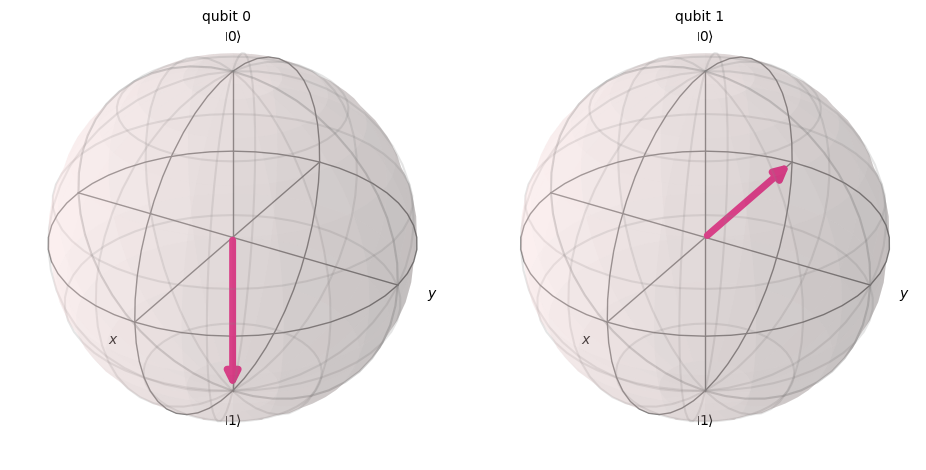


State prior to measurement (Q-Sphere):


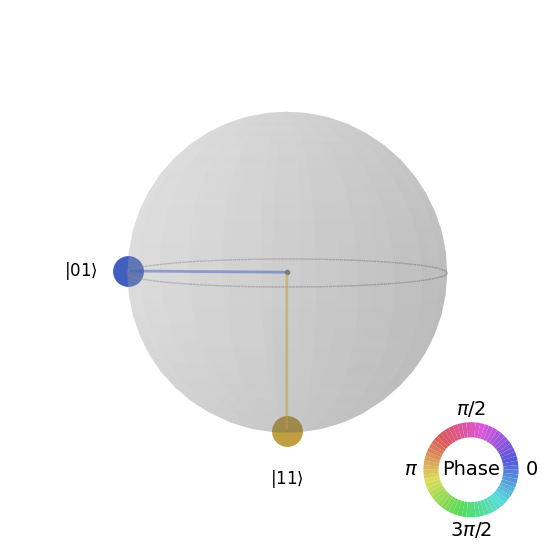

5. Measurement Analysis

Raw measurement counts: {'1': 1024}


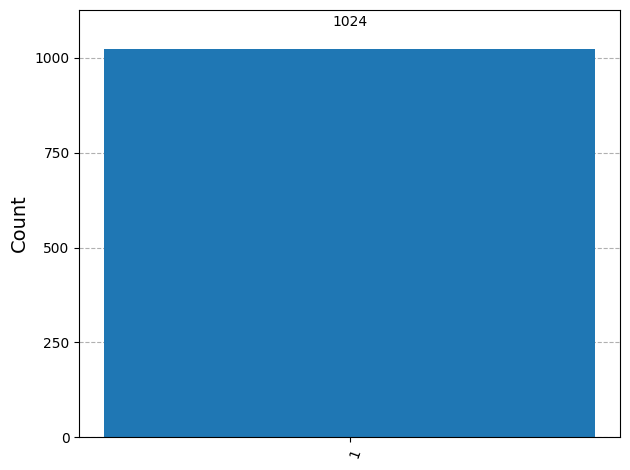

Conclusion: The measurement is 1. The function is BALANCED.


In [32]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_histogram, plot_bloch_multivector, plot_state_qsphere, array_to_latex
from IPython.display import display, Markdown

# You can toggle this between "balanced" and "constant"
oracle_type = "balanced" 

# 1. Set up Registers & Circuit
qr = QuantumRegister(2, name="q")
cr = ClassicalRegister(1, name="c")
qc = QuantumCircuit(qr, cr)

# 2. Initialisation: Prepare target qubit (q1) in |-> and query qubit (q0) in |+>
qc.x(1)
qc.h(0)
qc.h(1)
qc.barrier(label="Init")

# 3. Oracle Application
if oracle_type == "balanced":
    qc.cx(0, 1)  # CNOT creates a balanced function (f(x) = x)
elif oracle_type == "constant":
    pass         # Identity creates a constant function (f(x) = 0)
qc.barrier(label="Oracle")

# 4. Final Interference
qc.h(0)
qc.barrier(label="Interference")

# ==========================================
# EXTRACT EXACT MATH BEFORE MEASUREMENT
# ==========================================
# We calculate the Unitary Operator and Statevector here because 
# adding a measurement operation makes the circuit non-unitary.
unitary = Operator(qc)
final_state = Statevector(qc)

# 5. Measurement
qc.measure(0, cr)

# 6. Execute on AerSimulator
simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
result = job.result()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"Deutsch Algorithm Analysis: {oracle_type.capitalize()} Oracle"))

display(Markdown("1. Circuit Visualisation"))
display(qc.draw('mpl'))

display(Markdown("2. Unitary Evolution"))
print("The 4x4 unitary matrix describing this specific oracle circuit:")
display(array_to_latex(unitary.data, prefix="U_{circuit} = "))

display(Markdown("3. Quantum State Representation"))
print("Exact Statevector prior to measurement:")
display(final_state.draw('latex'))

display(Markdown("4. State Visualisation"))
print("State prior to measurement (Bloch Spheres):")
display(plot_bloch_multivector(final_state))

print("\nState prior to measurement (Q-Sphere):")
display(plot_state_qsphere(final_state))

display(Markdown("5. Measurement Analysis"))
counts = result.get_counts()
print(f"Raw measurement counts: {counts}")
display(plot_histogram(counts))

# Verification statement
measured_bit = list(counts.keys())[0]
if measured_bit == '1':
    print("Conclusion: The measurement is 1. The function is BALANCED.")
else:
    print("Conclusion: The measurement is 0. The function is CONSTANT.")